In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
raw_csv_path = Path("data/anes_timeseries_2020_csv_20220210.csv")
clean_csv_path = Path("data/policy_clean.csv")

print(f"Loading {raw_csv_path} ...")
df = pd.read_csv(raw_csv_path)

# Missing codes
MISSING = {-9, -8, -7, -6, -5, -4, -3, -2, -1, 99}
MISSING_THERM = {-9, -8, -7, -6, -5, -4, 998, 999}

def get_first(cols, exclude=MISSING):
    """Return first existing column in df (with missing codes -> NaN), else all-NaN series."""
    for c in cols:
        if c in df.columns:
            return df[c].replace(exclude, np.nan)
    return pd.Series(np.nan, index=df.index)

# Build policy columns with succinct names (<= 15 chars), except the three specified to remain as-is
policy = {}

# Keep these names exactly as requested
policy["ideology_7pt"] = get_first(["V201200"])
policy["ideology_3pt_signed"] = policy["ideology_7pt"].map({1: 1, 2: 1, 3: 1, 4: 0, 5: -1, 6: -1, 7: -1})
policy["party_id_signed"] = get_first(["V201228"]).map({1: -1, 2: 1, 3: 0, 5: 0, 0: 0})

# Immigration / rights / institutions
policy["imm_unauth"]   = get_first(["V201417"])        
policy["birthright"]   = get_first(["V201420x"])
policy["paid_leave"]   = get_first(["V201405x"])
policy["trump_corr"]   = get_first(["V201382x"])
policy["journ_access"] = get_first(["V201375x"])

# Guns / crime / courts
policy["gun_bkg_chk"]  = get_first(["V202341x"])
policy["illeg_child"]  = get_first(["V201423x"])
policy["death_pen"]    = get_first(["V201345x"])
policy["abortion"]     = get_first(["V201336"], exclude={-9, -8, 5})
policy["scotus_abort"] = get_first(["V201342x"])
policy["ar_ban"]       = get_first(["V202344x"])

#  economy
policy["econ_now"]     = get_first(["V201324"])
policy["voter_id"]     = get_first(["V201359x"])
policy["felon_vote"]   = get_first(["V201362x"])



# Health / education / spending
policy["vax_school"]   = get_first(["V202331x"])
policy["spend_border"] = get_first(["V201308x"])
policy["spend_welfare"]= get_first(["V201314x"])        
policy["spend_poor"]   = get_first(["V201320x"])
policy["spend_school"] = get_first(["V201305x"])

# Governance / social issues
policy["checks_power"] = get_first(["V201367"])
policy["border_wall"]  = get_first(["V201426x"])
policy["trans_bath"]   = get_first(["V201411x"])
policy["trans_military"]   = get_first(["V202390x"])

policy["lg_job"]  = get_first(["V201414x"])
policy["lg_marry"]  = get_first(["V201414x"])
policy["lg_refuse_service"]  = get_first(["V201408x"])

policy["police_force"] = get_first(["V202351"])

policy["assist_black"] = get_first(["V201258"])
policy['black_favor'] = get_first(["V202300"]) 
policy['diversity'] = get_first(["V202373x"])

policy["job_gov_guar"]     = get_first(["V201255"])
policy["govt_health"]  = get_first(["V201252"])
policy["obamacare"]    = get_first(["V202328x"])

# Spending / unrest / climate / foreign
policy["svc_spend"]    = get_first(["V201246"])
policy["def_spend"]    = get_first(["V201249"])
policy["urban_unrest"] = get_first(["V201429"])
policy["clim_imp"]     = get_first(["V202333"])
policy["rus_interf"]   = get_first(["V201428"])

# Feeling thermometers
policy["ft_trans"]     = get_first(["V202172"], exclude=MISSING_THERM)
policy["ft_union"]     = get_first(["V202162"], exclude=MISSING_THERM)
policy["ft_fem"]       = get_first(["V202160"], exclude=MISSING_THERM)
policy["ft_sci"]       = get_first(["V202173"], exclude=MISSING_THERM)
policy["ft_police"]    = get_first(["V202171"], exclude=MISSING_THERM)

# Environment / guns / military
policy["env_bus"]      = get_first(["V201262"])   

policy["ghg_emiss"]    = get_first(["V202336x"])
policy["gun_imp"]      = get_first(["V202338"])
policy["mil_force"]    = get_first(["V201350"])
policy['millionaire_tax'] = get_first(["V202325"])
policy['min_wage'] = get_first(["V202377"])

policy['free_trade'] = get_first(["V202361x"])
policy['intl_trade_job'] = get_first(["V202367x"])
# Assemble clean DataFrame
clean = pd.DataFrame(policy)

# Diagnostics
missing_in_file = [k for k, s in policy.items() if s.isna().all()]
if missing_in_file:
    print("Warning: missing raw columns for:", missing_in_file)

too_long = [c for c in clean.columns if c not in {"party_id_signed", "ideology_7pt", "ideology_3pt_signed"} and len(c) > 17]
if too_long:
    raise ValueError(f"These column names exceed 15 characters: {too_long}")

non_null_counts = clean.notna().sum().sort_values(ascending=False)
print("Non-null counts per column:\n", non_null_counts)

clean.to_csv(clean_csv_path, index=False)
print(f"Saved cleaned policy dataset to {clean_csv_path}")


Loading data/anes_timeseries_2020_csv_20220210.csv ...


/scratch/local/jobs/44156923/ipykernel_1296190/1451647990.py:10: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_csv_path)


Non-null counts per column:
 econ_now               8259
voter_id               8256
felon_vote             8251
spend_school           8247
checks_power           8243
paid_leave             8242
border_wall            8240
party_id_signed        8231
spend_border           8227
spend_poor             8225
birthright             8225
mil_force              8222
journ_access           8214
spend_welfare          8213
scotus_abort           8208
imm_unauth             8197
trump_corr             8195
lg_refuse_service      8166
lg_job                 8161
lg_marry               8161
rus_interf             8155
illeg_child            8131
death_pen              8113
trans_bath             7967
abortion               7900
urban_unrest           7713
assist_black           7403
ft_police              7388
gun_bkg_chk            7387
vax_school             7384
millionaire_tax        7384
clim_imp               7383
obamacare              7382
ar_ban                 7381
gun_imp            

In [34]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Get policy columns (exclude ideology/partisan columns)
policy_data = clean_normalized[policy_cols].dropna()

# Standardize the data (important for PCA)
scaler = StandardScaler()
policy_standardized = scaler.fit_transform(policy_data)

# Fit PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(policy_standardized)

# Create DataFrame with PC1 and PC2
df_pca = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2'],
    index=policy_data.index
)

# Get explained variance
explained_variance = pca.explained_variance_ratio_

print(f"PC1 Explained Variance: {explained_variance[0]:.4f} ({explained_variance[0]*100:.2f}%)")
print(f"PC2 Explained Variance: {explained_variance[1]:.4f} ({explained_variance[1]*100:.2f}%)")
print(f"Total Explained Variance: {explained_variance.sum():.4f} ({explained_variance.sum()*100:.2f}%)")

print("\nPCA Results DataFrame shape:", df_pca.shape)
print("\nFirst few rows:")
print(df_pca.head())

PC1 Explained Variance: 0.3914 (39.14%)
PC2 Explained Variance: 0.0416 (4.16%)
Total Explained Variance: 0.4330 (43.30%)

PCA Results DataFrame shape: (4275, 2)

First few rows:
         PC1       PC2
0  -7.606460 -1.161004
2   6.132774  0.302646
4  -6.460529  2.918680
6  -1.137880 -0.743097
10  0.054496  5.161237


In [30]:
policy

'spend_border'

In [25]:
issue_meta = {
    # Ideology / partisanship
    "ideology_7pt": {
        "area": "Ideology",
        "explanation": "Seven-point ideological self-placement on a liberal–conservative scale."
    },
    "ideology_3pt_signed": {
        "area": "Ideology",
        "explanation": "Collapsed ideology measure indicating liberal vs conservative orientation (signed)."
    },
    "party_id_signed": {
        "area": "Partisanship",
        "explanation": "Party identification coded as Democrat (−1), Republican (+1), and non-identifier/other (0)."
    },

    # Immigration
    "imm_unauth": {
        "area": "Immigration",
        "explanation": "Policy preferences regarding unauthorized/undocumented immigrants."
    },
    "birthright": {
        "area": "Immigration",
        "explanation": "Support for birthright citizenship for children born in the U.S. to non-citizen parents."
    },
    "illeg_child": {
        "area": "Immigration",
        "explanation": "Views on how the U.S. should handle children of undocumented immigrants."
    },
    "border_wall": {
        "area": "Immigration",
        "explanation": "Support for constructing a barrier/wall at the U.S.–Mexico border."
    },
    "spend_border": {
        "area": "Immigration",
        "explanation": "Preferences for federal spending levels on border security."
    },

    # Labor / family policy
    "paid_leave": {
        "area": "Labor",
        "explanation": "Support for paid parental/family leave policies for new parents and caregivers."
    },
    "ft_union": {
        "area": "Labor",
        "explanation": "Feeling thermometer rating toward labor unions."
    },
    "min_wage": {
        "area": "Labor",
        "explanation": "Support for raising the minimum wage / minimum-wage policy changes."
    },
    "job_gov_guar": {
        "area": "Labor",
        "explanation": "Support for a government-guaranteed job program (public employment guarantee)."
    },

    # Political institutions / media / accountability
    "checks_power": {
        "area": "Institutions",
        "explanation": "Views on checks and balances and whether branches of government should limit one another’s power."
    },
    "journ_access": {
        "area": "Institutions",
        "explanation": "Support for press/journalist access to government officials and government transparency norms."
    },
    "trump_corr": {
        "area": "Institutions",
        "explanation": "Perceptions of corruption involving Donald Trump and/or his administration."
    },
    "rus_interf": {
        "area": "Institutions",
        "explanation": "Concern about Russian interference in U.S. elections and related political influence operations."
    },

    # Elections / democracy
    "voter_id": {
        "area": "Elections",
        "explanation": "Support for voter identification requirements (e.g., photo ID laws)."
    },
    "felon_vote": {
        "area": "Elections",
        "explanation": "Support for restoring or extending voting rights to people with felony convictions."
    },

    # Economy / macro evaluation
    "econ_now": {
        "area": "Economy",
        "explanation": "Evaluation of the current national economy (retrospective economic assessment)."
    },

    # Guns / crime / punishment
    "gun_bkg_chk": {
        "area": "Guns",
        "explanation": "Support for background checks on gun purchases (including universal background checks)."
    },
    "ar_ban": {
        "area": "Guns",
        "explanation": "Support for banning assault rifles/assault weapons."
    },
    "gun_imp": {
        "area": "Guns",
        "explanation": "Importance placed on gun regulation as a political issue."
    },
    "death_pen": {
        "area": "Crime",
        "explanation": "Support for the death penalty/capital punishment for serious crimes."
    },

    # Abortion / courts
    "abortion": {
        "area": "Abortion",
        "explanation": "Attitudes toward abortion legality and access."
    },
    "scotus_abort": {
        "area": "Abortion",
        "explanation": "Views on Supreme Court decisions and judicial intervention related to abortion."
    },

    # Health policy
    "govt_health": {
        "area": "Health",
        "explanation": "Support for government-provided health insurance (e.g., single payer, public provision)."
    },
    "obamacare": {
        "area": "Health",
        "explanation": "Attitudes toward the Affordable Care Act (ACA/‘Obamacare’)."
    },
    "vax_school": {
        "area": "Health",
        "explanation": "Support for school vaccination requirements for children attending school."
    },

    # Spending / welfare / redistribution
    "spend_welfare": {
        "area": "Redistribution",
        "explanation": "Preferences for federal spending on welfare programs / public assistance."
    },
    "spend_poor": {
        "area": "Redistribution",
        "explanation": "Preferences for federal spending to aid the poor / anti-poverty programs."
    },
    "spend_school": {
        "area": "Education",
        "explanation": "Preferences for federal spending on public schools and K–12 education."
    },
    "svc_spend": {
        "area": "Redistribution",
        "explanation": "Preferences for government spending on services (general service provision)."
    },
    "def_spend": {
        "area": "Defense",
        "explanation": "Preferences for government spending on national defense and the military."
    },
    "millionaire_tax": {
        "area": "Redistribution",
        "explanation": "Support for taxes targeting millionaires."
    },

    # Climate / environment / regulation
    "clim_imp": {
        "area": "Climate",
        "explanation": "Importance assigned to climate change as an issue."
    },
    "ghg_emiss": {
        "area": "Climate",
        "explanation": "Support for regulating greenhouse gas emissions / carbon emissions."
    },
    "env_bus": {
        "area": "Climate",
        "explanation": "Tradeoff between environmental protection and business regulation/deregulation."
    },

    # Foreign policy / trade / military
    "mil_force": {
        "area": "ForeignPolicy",
        "explanation": "Support for the use of U.S. military force internationally."
    },
    "free_trade": {
        "area": "Trade",
        "explanation": "Support for free trade policies and reducing trade barriers."
    },
    "intl_trade_job": {
        "area": "Trade",
        "explanation": "Beliefs about international trade’s impact on jobs (job creation/loss from trade)."
    },

    # Policing / unrest
    "police_force": {
        "area": "Policing",
        "explanation": "Support for police use of force / policing practices."
    },
    "urban_unrest": {
        "area": "Policing",
        "explanation": "Concern about urban unrest, protests, and disorder."
    },
    "ft_police": {
        "area": "Policing",
        "explanation": "Feeling thermometer rating toward police."
    },

    # Race / diversity
    "assist_black": {
        "area": "Race",
        "explanation": "Support for government assistance to Black Americans / addressing racial inequality."
    },
    "black_favor": {
        "area": "Race",
        "explanation": "Attitudes toward whether Black people should receive favoritism in society/politics."
    },
    "diversity": {
        "area": "Race",
        "explanation": "Attitudes toward diversity initiatives and/or the importance of diversity."
    },

    # LGBTQ / gender identity
    "trans_bath": {
        "area": "LGBTQ",
        "explanation": "Views on transgender bathroom access policies."
    },
    "trans_military": {
        "area": "LGBTQ",
        "explanation": "Views on transgender people serving in the U.S. military."
    },
    "lg_job": {
        "area": "LGBTQ",
        "explanation": "Views on legal protections against job discrimination for gay/lesbian people."
    },
    "lg_marry": {
        "area": "LGBTQ",
        "explanation": "Support for same-sex marriage / marriage rights for gay and lesbian couples."
    },
    "lg_refuse_service": {
        "area": "LGBTQ",
        "explanation": "Views on refusing service to same-sex couples."
    },

    # Feeling thermometers
    "ft_trans": {
        "area": "LGBTQ",
        "explanation": "Feeling thermometer rating toward transgender people."
    },
    "ft_fem": {
        "area": "Gender",
        "explanation": "Feeling thermometer rating toward feminists."
    },
    "ft_sci": {
        "area": "Institutions",
        "explanation": "Feeling thermometer rating toward scientists."
    },
}


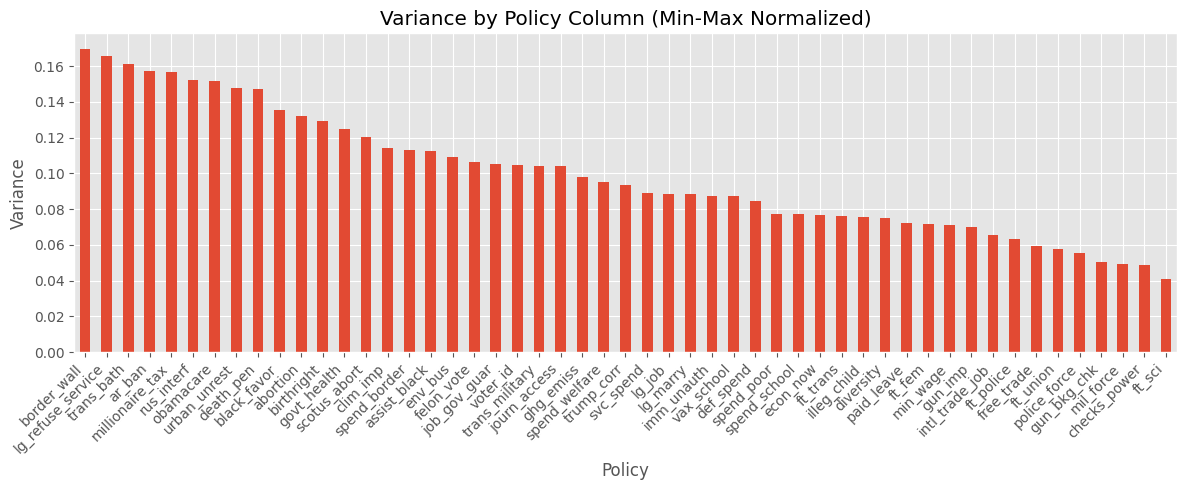

In [26]:
import matplotlib.pyplot as plt

# Load cleaned policy data
clean = pd.read_csv("data/policy_clean.csv")

# Define columns to exclude from normalization (ideology and partisanship)
exclude_cols = ['party_id_signed', 'ideology_7pt', 'ideology_3pt_signed']

# Get policy columns (exclude ideology/partisan columns)
policy_cols = [col for col in clean.columns if col not in exclude_cols]

# Min-max normalize policy columns only
col_min = clean[policy_cols].min(skipna=True)
col_max = clean[policy_cols].max(skipna=True)
col_range = col_max - col_min
safe_range = col_range.replace(0, np.nan)

clean_normalized = clean.copy()
clean_normalized[policy_cols] = (clean[policy_cols] - col_min) / safe_range

# Calculate variance for each policy
variance = {col: clean_normalized[col].var(skipna=True) for col in policy_cols}
variance_sorted = dict(sorted(variance.items(), key=lambda x: x[1], reverse=True))

# Plot 1: Variance
plt.figure(figsize=(12, 5))
pd.Series(variance_sorted).plot(kind='bar')
plt.title('Variance by Policy Column (Min-Max Normalized)')
plt.ylabel('Variance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

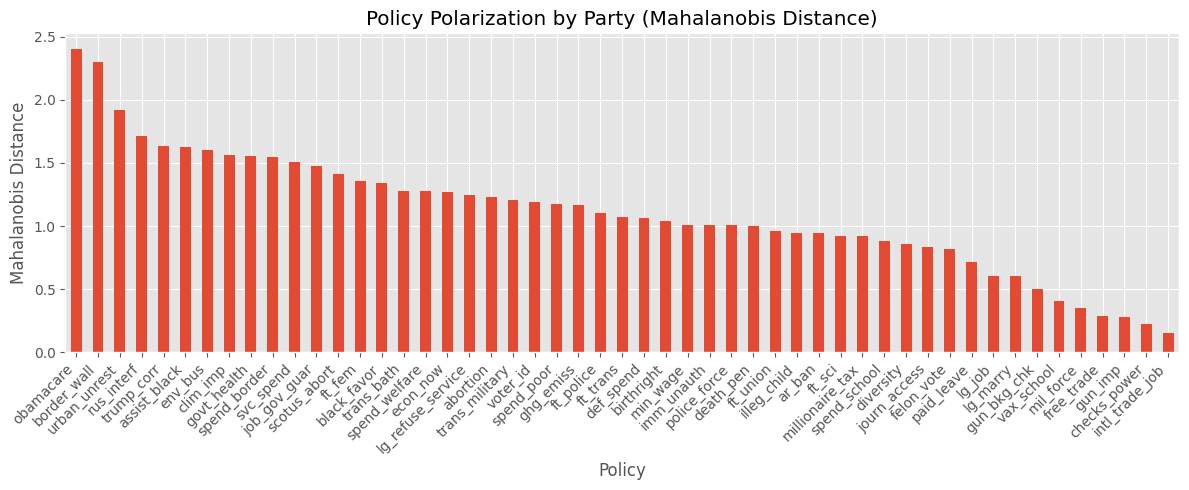


Top 10 Most Polarized Policies (Mahalanobis):
1. obamacare: 2.4081
2. border_wall: 2.3030
3. urban_unrest: 1.9199
4. rus_interf: 1.7166
5. trump_corr: 1.6373
6. assist_black: 1.6231
7. env_bus: 1.5994
8. clim_imp: 1.5654
9. govt_health: 1.5561
10. spend_border: 1.5508


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculate polarization by party for each policy (using Mahalanobis Distance)
polarization = {}

for col in policy_cols:
    # Get data for each party (drop NaNs to ensure valid variance calc)
    dem_data = clean_normalized[col][clean['party_id_signed'] == -1].dropna()
    rep_data = clean_normalized[col][clean['party_id_signed'] == 1].dropna()
    
    # We need at least 2 points to calculate variance
    if len(dem_data) < 2 or len(rep_data) < 2:
        polarization[col] = 0.0
        continue
    
    # 1. Calculate Means
    mu_d = dem_data.mean()
    mu_r = rep_data.mean()
    
    # 2. Calculate Pooled Variance (1D equivalent of Pooled Covariance Matrix)
    var_d = dem_data.var()
    var_r = rep_data.var()
    
    # Average the variances (consistent with your LLM pipeline's `(cov_d + cov_r) / 2`)
    pool_var = (var_d + var_r) / 2
    
    # Regularization to prevent division by zero (same as your `+ np.eye * 1e-6`)
    pool_var += 1e-6 
    
    # 3. Calculate Mahalanobis Distance
    # Formula for 1D: |Mean_Diff| / sqrt(Pooled_Variance)
    polarization[col] = abs(mu_r - mu_d) / np.sqrt(pool_var)

# Sort polarization for plotting
polarization_sorted = dict(sorted(polarization.items(), key=lambda x: x[1], reverse=True))

# Plot 2: Polarization
plt.figure(figsize=(12, 5))
pd.Series(polarization_sorted).plot(kind='bar')
plt.title('Policy Polarization by Party (Mahalanobis Distance)')
plt.ylabel('Mahalanobis Distance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Polarized Policies (Mahalanobis):")
for i, (policy, value) in enumerate(list(polarization_sorted.items())[:10], 1):
    print(f"{i}. {policy}: {value:.4f}")

In [28]:
# save polarization and variance as csv
df_results = pd.DataFrame({
    'mahalanobis_distance': pd.Series(polarization),
    'variance': pd.Series(variance)
}).reset_index().rename(columns={"index": "issue"})
df_meta = (
    pd.DataFrame.from_dict(issue_meta, orient="index")
      .reset_index()
      .rename(columns={"index": "issue"})
)
df_out = df_results.merge(df_meta, on="issue", how="left")
missing = df_out[df_out["area"].isna()]["issue"].tolist()
print(f"missing metadata for issues: {missing}")
df_out.to_csv("policy_polarization.csv", index=False)

missing metadata for issues: []


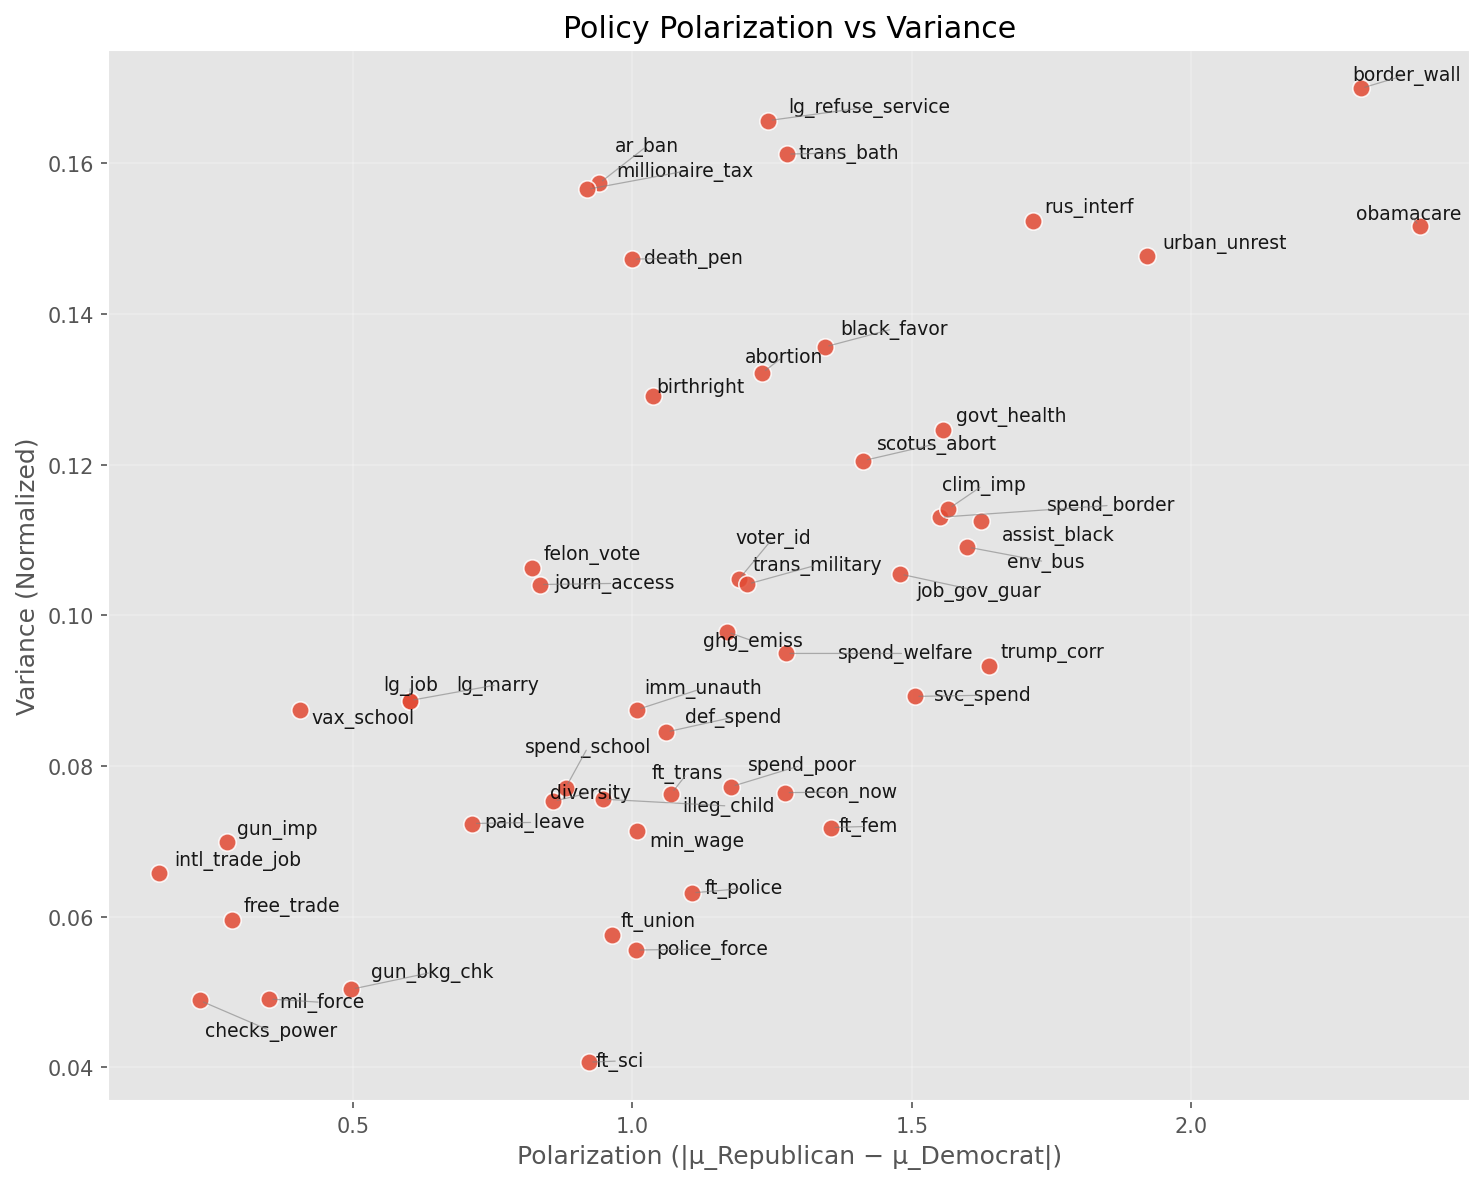

In [29]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Extract x and y values
x_values = [polarization[p] for p in policy_cols]
y_values = [variance[p] for p in policy_cols]

# Scatter plot
ax.scatter(
    x_values,
    y_values,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
)

# Create text objects (start exactly at the point)
texts = []
for p, x, y in zip(policy_cols, x_values, y_values):
    texts.append(
        ax.text(
            x,
            y,
            p,
            fontsize=9,
            alpha=0.9,
        )
    )

ax.set_xlabel("Polarization (|μ_Republican − μ_Democrat|)")
ax.set_ylabel("Variance (Normalized)")
ax.set_title("Policy Polarization vs Variance")
ax.grid(True, alpha=0.25)

# Add modest padding
x_pad = 0.04 * (max(x_values) - min(x_values) or 1)
y_pad = 0.04 * (max(y_values) - min(y_values) or 1)
ax.set_xlim(min(x_values) - x_pad, max(x_values) + x_pad)
ax.set_ylim(min(y_values) - y_pad, max(y_values) + y_pad)

# Strongly constrained adjustment
adjust_text(
    texts,
    x=x_values,
    y=y_values,
    ax=ax,

    # Keep labels close
    expand_points=(1.05, 1.1),
    expand_text=(1.05, 1.1),

    # Weak repulsion forces
    force_points=(0.03, 0.1),
    force_text=(0.03, 0.1),

    # Explicit attraction back to the point
    pull_points=(0.6, 0.6),
    pull_text=(0.6, 0.6),

    # Limit iterations to prevent drift
    lim=100,

    arrowprops=dict(
        arrowstyle="-",
        color="grey",
        lw=0.6,
        alpha=0.6,
    ),
)

fig.tight_layout()
plt.show()
